# **Análises Quantitativas das Variáveis de Latência dos Benchmarks de PDS**

In [ ]:
####### pacotes necessários ########
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import tiktoken
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, t, bootstrap

# Inicializa o tokenizador como uma variável global ou dentro da função
enc = tiktoken.get_encoding("cl100k_base")

# configurações para exibir todas as linhas do DataFrame
pd.set_option('display.max_rows', None)

## **1. Importação e Limpeza dos Dados**

In [2]:
# Insira os caminhos exatos dos seus 6 arquivos finais
arquivos_bruto = [
    "resultados_brutos/geracao_bruto_cyankiwi_Ministral-3-8B-Instruct-2512-AWQ-8bit_pergunta_pt_pergunta_en_COMPLETO.csv", # Substitua pelo real
    "resultados_brutos/geracao_bruto_deepseek-v4-pro_pergunta_pt_pergunta_en_COMPLETO.csv",                                # Substitua pelo real
    "resultados_brutos/geracao_bruto_gpt-5_pergunta_pt_pergunta_en_COMPLETO.csv"                                           # Substitua pelo real
]

arquivos_tutor = [
    "resultados_brutos/geracao_tutor_cyankiwi_Ministral-3-8B-Instruct-2512-AWQ-8bit_pergunta_pt_pergunta_en_COMPLETO.csv", # Substitua pelo real
    "resultados_brutos/geracao_tutor_deepseek-v4-pro_pergunta_pt_pergunta_en_COMPLETO.csv",                                # Substitua pelo real
    "resultados_brutos/geracao_tutor_gpt-5_pergunta_pt_pergunta_en_COMPLETO.csv"                                           # Substitua pelo real
]

# Dicionário para encurtar e limpar os nomes dos modelos
nomes_modelos = {
    "cyankiwi/Ministral-3-8B-Instruct-2512-AWQ-8bit": "Ministral3-8B",
    "deepseek-v4-pro": "DeepSeek-V4-Pro",
    "gpt-5": "GPT-5"
}

In [3]:
def contar_tokens_visiveis(texto):
    if pd.isna(texto):
        return 0
    return len(enc.encode(str(texto)))

def carregar_e_limpar(lista_arquivos, modo_teste):
    df_lista = []
    for arquivo in lista_arquivos:
        df = pd.read_csv(arquivo)
        
        # Cria a coluna Modo
        df['Modo'] = modo_teste
        
        # 1. Renomeia os modelos
        df['Modelo_Limpo'] = df['Modelo'].replace(nomes_modelos)
        
        # 2. Cria a variação elegante
        df['Variacao'] = df['Modelo_Limpo'] + " - " + df['Idioma']
        
        # 3. CORREÇÃO CIENTÍFICA: Tokenização real do texto gerado
        # Isso substitui a contagem da API pelo volume real de leitura do aluno
        df['Tokens_Out'] = df['Resposta_Gerada'].apply(contar_tokens_visiveis)
        
        # 4. Recalcula o Throughput Real (Tokens visíveis / Tempo real de escrita)
        # Usamos ITL_s pois é o tempo efetivo que o modelo levou para "escrever" na tela
        df['Throughput_tps'] = df.apply(
            lambda row: row['Tokens_Out'] / row['ITL_s'] if row['ITL_s'] > 0 else 0, 
            axis=1
        )
        
        # Remove a questão problemática
        df = df.drop(index=[9, 69], errors='ignore')
        
        df_lista.append(df)
        
    return pd.concat(df_lista, ignore_index=True)

In [5]:
# Agora os seus DataFrames já nascem com os dados corrigidos!
df_bruto = carregar_e_limpar(arquivos_bruto, "Bruto")
df_tutor = carregar_e_limpar(arquivos_tutor, "Tutor")

## **2. Tabela Resumo (ESTATÍSTICA DESCRITIVA)**

In [6]:
df_total = pd.concat([df_bruto, df_tutor], ignore_index=True)

tabela_resumo = df_total.groupby(['Modo', 'Variacao'])['Tokens_Out'].agg(
    Media='mean',
    Mediana='median',
    Desvio_Padrao='std',
    Minimo='min',
    Maximo='max'
).round(2).reset_index()

In [7]:
print("="*60)
print("TABELA RESUMO - VERBOSIDADE (Tokens Gerados)")
print("="*60)
display(tabela_resumo) # Mostra a tabela bonita no Jupyter para o seu orientador

TABELA RESUMO - VERBOSIDADE (Tokens Gerados)


,Modo,Variacao,Media,Mediana,Desvio_Padrao,Minimo,Maximo
0,Bruto,DeepSeek-V4-Pro - EN,476.39,435.0,274.22,73,1583
1,Bruto,DeepSeek-V4-Pro - PT,559.39,519.0,327.20,54,1565
2,Bruto,GPT-5 - EN,292.29,232.0,180.84,65,904
3,Bruto,GPT-5 - PT,362.64,275.0,270.12,49,1506
4,Bruto,Ministral3-8B - EN,2387.02,1196.0,5407.29,226,31068
5,Bruto,Ministral3-8B - PT,1868.71,1182.0,3990.77,318,31519
6,Tutor,DeepSeek-V4-Pro - EN,618.39,542.0,317.51,42,1861
7,Tutor,DeepSeek-V4-Pro - PT,802.14,794.0,424.28,47,2499
8,Tutor,GPT-5 - EN,901.29,887.0,461.40,116,2008
9,Tutor,GPT-5 - PT,1076.76,1034.0,557.97,174,2493


## **3. Análise de Normalidade (SHAPIRO-WILK)**

In [8]:
print("\n" + "="*60)
print("TESTE DE NORMALIDADE DE SHAPIRO-WILK (Alpha = 0.10)")
print("="*60)

grupos_normais = True

for modo, df_modo in [("Bruto", df_bruto), ("Tutor", df_tutor)]:
    for variacao in df_modo['Variacao'].unique():
        dados = df_modo[df_modo['Variacao'] == variacao]['Tokens_Out'].dropna()
        stat, p_valor = shapiro(dados)
        
        is_normal = p_valor > 0.10
        if not is_normal:
            grupos_normais = False
            
        status = "NORMAL" if is_normal else "NÃO NORMAL"
        print(f"[{modo}] {variacao:^30} | p-valor: {p_valor:.4f} -> {status}")

print("\nConclusão da Normalidade:")
if grupos_normais:
    print("Todos os grupos seguem distribuição normal. Usaremos o TESTE T para comparação.")
else:
    print("Pelo menos um grupo violou a normalidade. Usaremos o TESTE DE MANN-WHITNEY.")


TESTE DE NORMALIDADE DE SHAPIRO-WILK (Alpha = 0.10)
[Bruto]       Ministral3-8B - PT       | p-valor: 0.0000 -> NÃO NORMAL
[Bruto]       Ministral3-8B - EN       | p-valor: 0.0000 -> NÃO NORMAL
[Bruto]      DeepSeek-V4-Pro - PT      | p-valor: 0.0141 -> NÃO NORMAL
[Bruto]      DeepSeek-V4-Pro - EN      | p-valor: 0.0002 -> NÃO NORMAL
[Bruto]           GPT-5 - PT           | p-valor: 0.0000 -> NÃO NORMAL
[Bruto]           GPT-5 - EN           | p-valor: 0.0007 -> NÃO NORMAL
[Tutor]       Ministral3-8B - PT       | p-valor: 0.0278 -> NÃO NORMAL
[Tutor]       Ministral3-8B - EN       | p-valor: 0.0000 -> NÃO NORMAL
[Tutor]      DeepSeek-V4-Pro - PT      | p-valor: 0.0013 -> NÃO NORMAL
[Tutor]      DeepSeek-V4-Pro - EN      | p-valor: 0.0015 -> NÃO NORMAL
[Tutor]           GPT-5 - PT           | p-valor: 0.0498 -> NÃO NORMAL
[Tutor]           GPT-5 - EN           | p-valor: 0.2255 -> NORMAL

Conclusão da Normalidade:
Pelo menos um grupo violou a normalidade. Usaremos o TESTE DE MANN-WHITN

## **4. Análide Gráfica**

/tmp/ipykernel_2328240/2122430629.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bruto, x='Variacao', y='Tokens_Out', order=ordem_bruto, ax=axes[0], palette="Blues_r")
/tmp/ipykernel_2328240/2122430629.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_2328240/2122430629.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tutor, x='Variacao', y='Tokens_Out', order=ordem_tutor, ax=axes[1], palette="Oranges_r")
/tmp/ipykernel_2328240/2122430629.py:18: UserWarning: set_ticklabels() should only be 

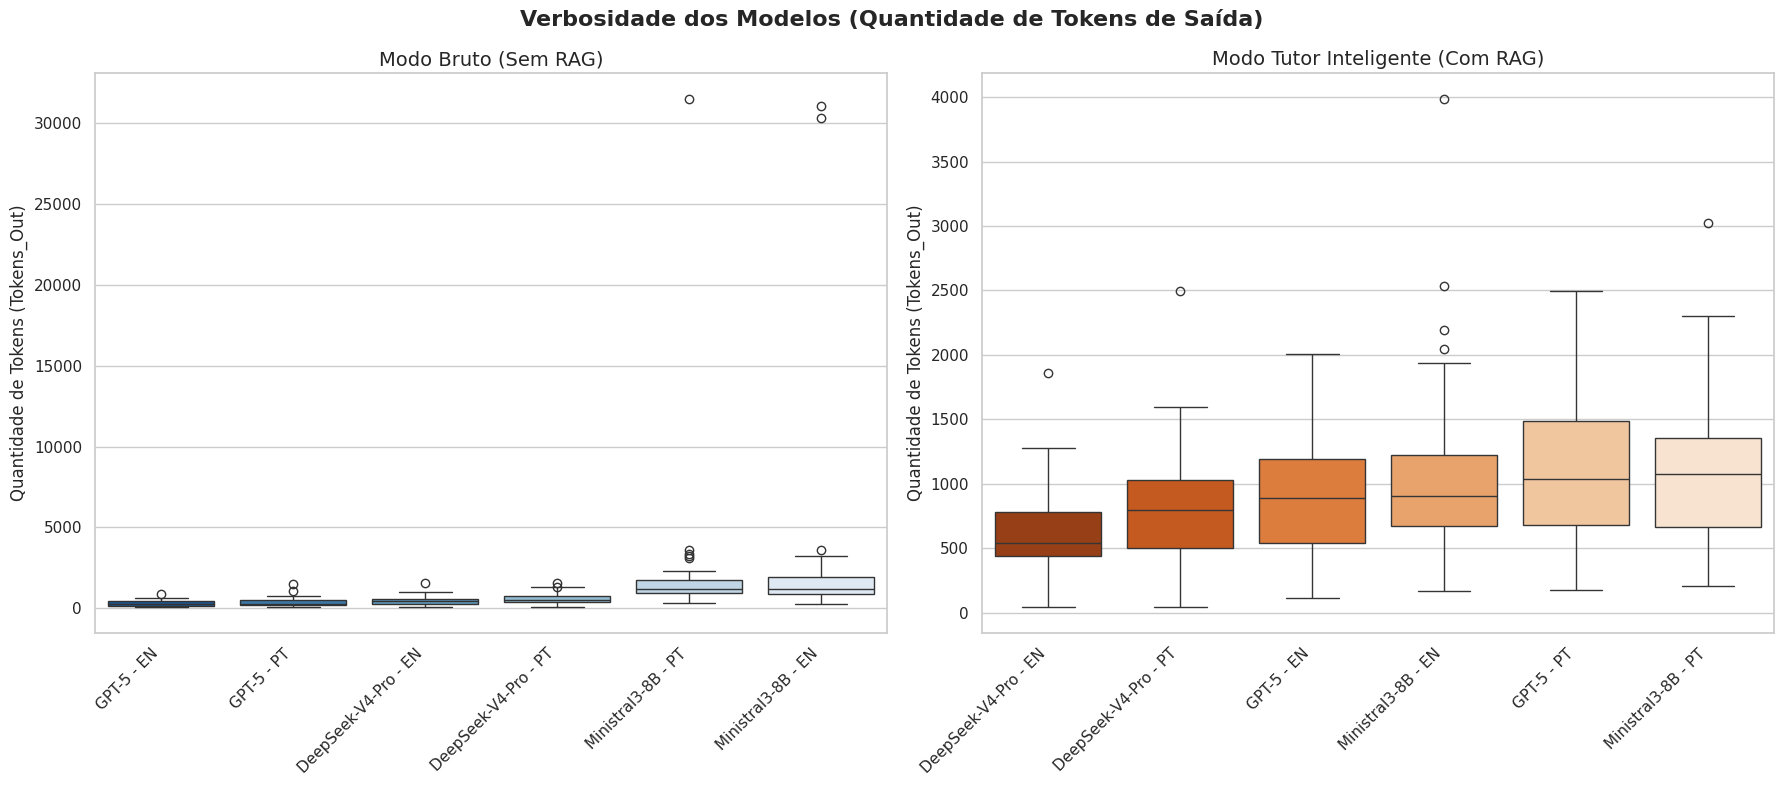

In [9]:
sns.set_theme(style="whitegrid")
# Alterado: sharey=False permite que cada gráfico tenha sua própria escala
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)
fig.suptitle('Verbosidade dos Modelos (Quantidade de Tokens de Saída)', fontsize=16, fontweight='bold')

# Ordenar Bruto
ordem_bruto = df_bruto.groupby('Variacao')['Tokens_Out'].median().sort_values().index
sns.boxplot(data=df_bruto, x='Variacao', y='Tokens_Out', order=ordem_bruto, ax=axes[0], palette="Blues_r")
axes[0].set_title('Modo Bruto (Sem RAG)', fontsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_xlabel('')
axes[0].set_ylabel('Quantidade de Tokens (Tokens_Out)', fontsize=12)

# Ordenar Tutor
ordem_tutor = df_tutor.groupby('Variacao')['Tokens_Out'].median().sort_values().index
sns.boxplot(data=df_tutor, x='Variacao', y='Tokens_Out', order=ordem_tutor, ax=axes[1], palette="Oranges_r")
axes[1].set_title('Modo Tutor Inteligente (Com RAG)', fontsize=14)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_xlabel('')
# Alterado: Adicionado o rótulo do eixo Y de volta para o gráfico do Tutor
axes[1].set_ylabel('Quantidade de Tokens (Tokens_Out)', fontsize=12) 

plt.tight_layout()
plt.show()

## **5. Testes de Ccomparação (A vs B)**

In [10]:
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu, t, bootstrap

def realizar_testes_estatisticos(df_analise, ordem, alpha=0.10):
    resultados_testes = []
    
    for i in range(len(ordem) - 1):
        grupo1 = ordem[i]
        grupo2 = ordem[i+1]
        
        dados1 = df_analise[df_analise['Variacao'] == grupo1]['Tokens_Out'].dropna()
        dados2 = df_analise[df_analise['Variacao'] == grupo2]['Tokens_Out'].dropna()
        
        if grupos_normais:
            # Teste T
            stat, p_val = ttest_ind(dados1, dados2, equal_var=False, alternative='less')
            nome_teste = "Teste T"
            
            n1, n2 = len(dados1), len(dados2)
            v1, v2 = np.var(dados1, ddof=1), np.var(dados2, ddof=1)
            se = np.sqrt(v1/n1 + v2/n2)
            df_welch = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
            t_crit = t.ppf(0.95, df_welch)
            
            diff = np.mean(dados1) - np.mean(dados2)
            ci_inf, ci_sup = diff - t_crit * se, diff + t_crit * se
            metrica = "Médias"
        else:
            # Mann-Whitney
            stat, p_val = mannwhitneyu(dados1, dados2, alternative='less')
            nome_teste = "Mann-Whitney"
            
            def diff_medianas(x, y, axis=-1):
                return np.median(x, axis=axis) - np.median(y, axis=axis)
            
            res_boot = bootstrap((dados1, dados2), diff_medianas, confidence_level=0.90, method='percentile', random_state=42)
            ci_inf, ci_sup = res_boot.confidence_interval.low, res_boot.confidence_interval.high
            diff = np.median(dados1) - np.median(dados2)
            metrica = "Medianas"
            
        resultados_testes.append({
            "Comparacao": f"{grupo1} vs {grupo2}",
            "Teste": nome_teste,
            "p-valor": p_val,
            "Significant": "SIM" if p_val < alpha else "NÃO",
            f"Diff_{metrica}": diff,
            "IC_90_Inf": ci_inf,
            "IC_90_Sup": ci_sup
        })
        
    return pd.DataFrame(resultados_testes)

In [11]:
grupos_normais = False

# --- Como rodar e salvar os resultados ---
df_resultados_bruto = realizar_testes_estatisticos(df_bruto, ordem_bruto)
df_resultados_tutor = realizar_testes_estatisticos(df_tutor, ordem_tutor)

# Mostrar a tabela de resultados estatísticos prontinha para o seu relatório:
print("--- Resultados Estatísticos: Bruto ---")
display(df_resultados_bruto)
print("\n--- Resultados Estatísticos: Tutor ---")
display(df_resultados_tutor)

--- Resultados Estatísticos: Bruto ---


,Comparacao,Teste,p-valor,Significant,Diff_Medianas,IC_90_Inf,IC_90_Sup
0,GPT-5 - EN vs GPT-5 - PT,Mann-Whitney,1.039302e-01,NÃO,-43.0,-124.0,38.0
1,GPT-5 - PT vs DeepSeek-V4-Pro - EN,Mann-Whitney,2.695622e-03,SIM,-160.0,-224.0,-80.0
2,DeepSeek-V4-Pro - EN vs DeepSeek-V4-Pro - PT,Mann-Whitney,1.063807e-01,NÃO,-84.0,-167.0,42.0
3,DeepSeek-V4-Pro - PT vs Ministral3-8B - PT,Mann-Whitney,2.442710e-13,SIM,-663.0,-870.0,-537.0
4,Ministral3-8B - PT vs Ministral3-8B - EN,Mann-Whitney,4.295121e-01,NÃO,-14.0,-252.0,217.0



--- Resultados Estatísticos: Tutor ---


,Comparacao,Teste,p-valor,Significant,Diff_Medianas,IC_90_Inf,IC_90_Sup
0,DeepSeek-V4-Pro - EN vs DeepSeek-V4-Pro - PT,Mann-Whitney,0.006161,SIM,-252.0,-363.0,-67.0
1,DeepSeek-V4-Pro - PT vs GPT-5 - EN,Mann-Whitney,0.099155,SIM,-93.0,-262.0,107.2
2,GPT-5 - EN vs Ministral3-8B - EN,Mann-Whitney,0.171747,NÃO,-18.0,-231.0,94.1
3,Ministral3-8B - EN vs GPT-5 - PT,Mann-Whitney,0.293353,NÃO,-129.0,-335.0,167.0
4,GPT-5 - PT vs Ministral3-8B - PT,Mann-Whitney,0.417919,NÃO,-40.0,-304.0,226.0


Para a análise da verbosidade dos modelos, optou-se pelo teste não-paramétrico de **Mann-Whitney U**, visto que a distribuição do número de *tokens* de saída não segue o pressuposto de normalidade exigido pelo teste $t$ de Student. As hipóteses formuladas para a comparação entre dois modelos adjacentes ($G_1$ e $G_2$), ordenados de forma crescente pela mediana de verbosidade, são:

* **Hipótese Nula ($H_0$):** A distribuição da verbosidade de $G_1$ é estocasticamente igual à de $G_2$, ou seja, $P(X_{G1} > X_{G2}) = P(X_{G2} > X_{G1})$.
* **Hipótese Alternativa ($H_1$):** A distribuição da verbosidade de $G_1$ é estocasticamente menor que a de $G_2$ ($H_1: P(X_{G1} > X_{G2}) < 0.5$).

**Critérios de Significância:**
O teste foi aplicado de forma **unilateral** (`alternative='less'`), alinhado à ordenação prévia das medianas no gráfico. Para a determinação de grupos estatisticamente equivalentes (etiquetas G1, G2, G3), estabeleceu-se um nível de significância de $\alpha = 0.10$. A ausência de rejeição da hipótese nula ($p \ge 0.10$) entre modelos adjacentes implica que, apesar das variações nominais nas medianas, não há evidência estatística para classificar um modelo como mais verboso que o outro dentro do mesmo grupo.

In [12]:
# ==========================================================
# FUNÇÃO DE AGRUPAMENTO ESTATÍSTICO (CLD - Adjacent)
# ==========================================================
def calcular_grupos_estatisticos(df_analise, variacoes_ordenadas, alpha=0.10):
    """
    Compara modelos adjacentes. Se p >= 0.10, pertencem ao mesmo grupo estatístico.
    Se p < 0.10 (diferença significativa), inicia-se um novo grupo.
    """
    grupos = []
    grupo_atual = 1
    
    for i in range(len(variacoes_ordenadas)):
        if i == 0:
            grupos.append(f"G{grupo_atual}")
        else:
            dados_anterior = df_analise[df_analise['Variacao'] == variacoes_ordenadas[i-1]]['Tokens_Out'].dropna()
            dados_atual = df_analise[df_analise['Variacao'] == variacoes_ordenadas[i]]['Tokens_Out'].dropna()
            
            # Teste bilateral para verificar "igualdade" (falha em rejeitar H0)
            stat, p_val = mannwhitneyu(dados_anterior, dados_atual, alternative='two-sided')
            
            if p_val < alpha: # Se houver diferença real, pula para o próximo grupo
                grupo_atual += 1
                
            grupos.append(f"G{grupo_atual}")
            
    return grupos

In [13]:
# ==========================================================
# CONFIGURAÇÃO VISUAL (CORES E BORDAS)
# ==========================================================
# Cores internas (Facecolor) para os Modelos
cores_modelo = {
    'Ministral3-8B': '#1f77b4',     # Azul
    'DeepSeek-V4-Pro': '#2ca02c',   # Verde
    'GPT-5': '#ff7f0e'              # Laranja
}

# Cores do contorno (Edgecolor) para o Idioma
cores_idioma = {
    'PT': '#000000', # Contorno Preto (Forte)
    'EN': '#d62728'  # Contorno Vermelho
}

In [14]:
def plotar_dotplot(ax, df, titulo):
    # 1. Calcula as medianas e ordena
    df_med = df.groupby(['Variacao', 'Modelo_Limpo', 'Idioma'])['Tokens_Out'].median().reset_index()
    df_med = df_med.sort_values(by='Tokens_Out').reset_index(drop=True)
    
    # 2. Calcula os grupos estatísticos (G1, G2...)
    df_med['Grupo_Estatistico'] = calcular_grupos_estatisticos(df, df_med['Variacao'].tolist())
    
    # Grid e linha de base
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Offset para colocar o texto acima da bola sem colar
    range_y = df_med['Tokens_Out'].max() - df_med['Tokens_Out'].min()
    offset_texto = range_y * 0.08
    
    # 3. Plota os pontos individualmente para controle total de cor e borda
    for i, row in df_med.iterrows():
        ax.scatter(
            row['Variacao'], 
            row['Tokens_Out'], 
            s=600, # Tamanho da bola (bem grande para ver a cor de dentro)
            facecolors=cores_modelo[row['Modelo_Limpo']], 
            edgecolors=cores_idioma[row['Idioma']], 
            linewidths=4, # Espessura do contorno
            zorder=3      # Garante que a bola fique por cima das linhas de grade
        )
        
        # 4. Escreve o Grupo Estatístico (Ex: G1) em cima da bola
        ax.text(
            row['Variacao'], 
            row['Tokens_Out'] + offset_texto, 
            row['Grupo_Estatistico'], 
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333'
        )
        
        # Opcional: Escreve o valor da mediana embaixo da bola
        ax.text(
            row['Variacao'], 
            row['Tokens_Out'] - (offset_texto*1.2), 
            f"{row['Tokens_Out']:.1f}", 
            ha='center', va='top', fontsize=10, color='gray'
        )

    # 5. Formatação dos Eixos
    ax.set_title(titulo, fontsize=15, pad=15)
    ax.set_xticklabels(df_med['Variacao'], rotation=45, ha='right', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Mediana de Tokens (Tokens_Out)', fontsize=12)
    
    # Expande o limite Y para o texto não ser cortado
    ax.set_ylim(df_med['Tokens_Out'].min() - (range_y * 0.2), df_med['Tokens_Out'].max() + (range_y * 0.2))

/tmp/ipykernel_2157902/3723293926.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_med['Variacao'], rotation=45, ha='right', fontsize=11)
/tmp/ipykernel_2157902/3723293926.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_med['Variacao'], rotation=45, ha='right', fontsize=11)


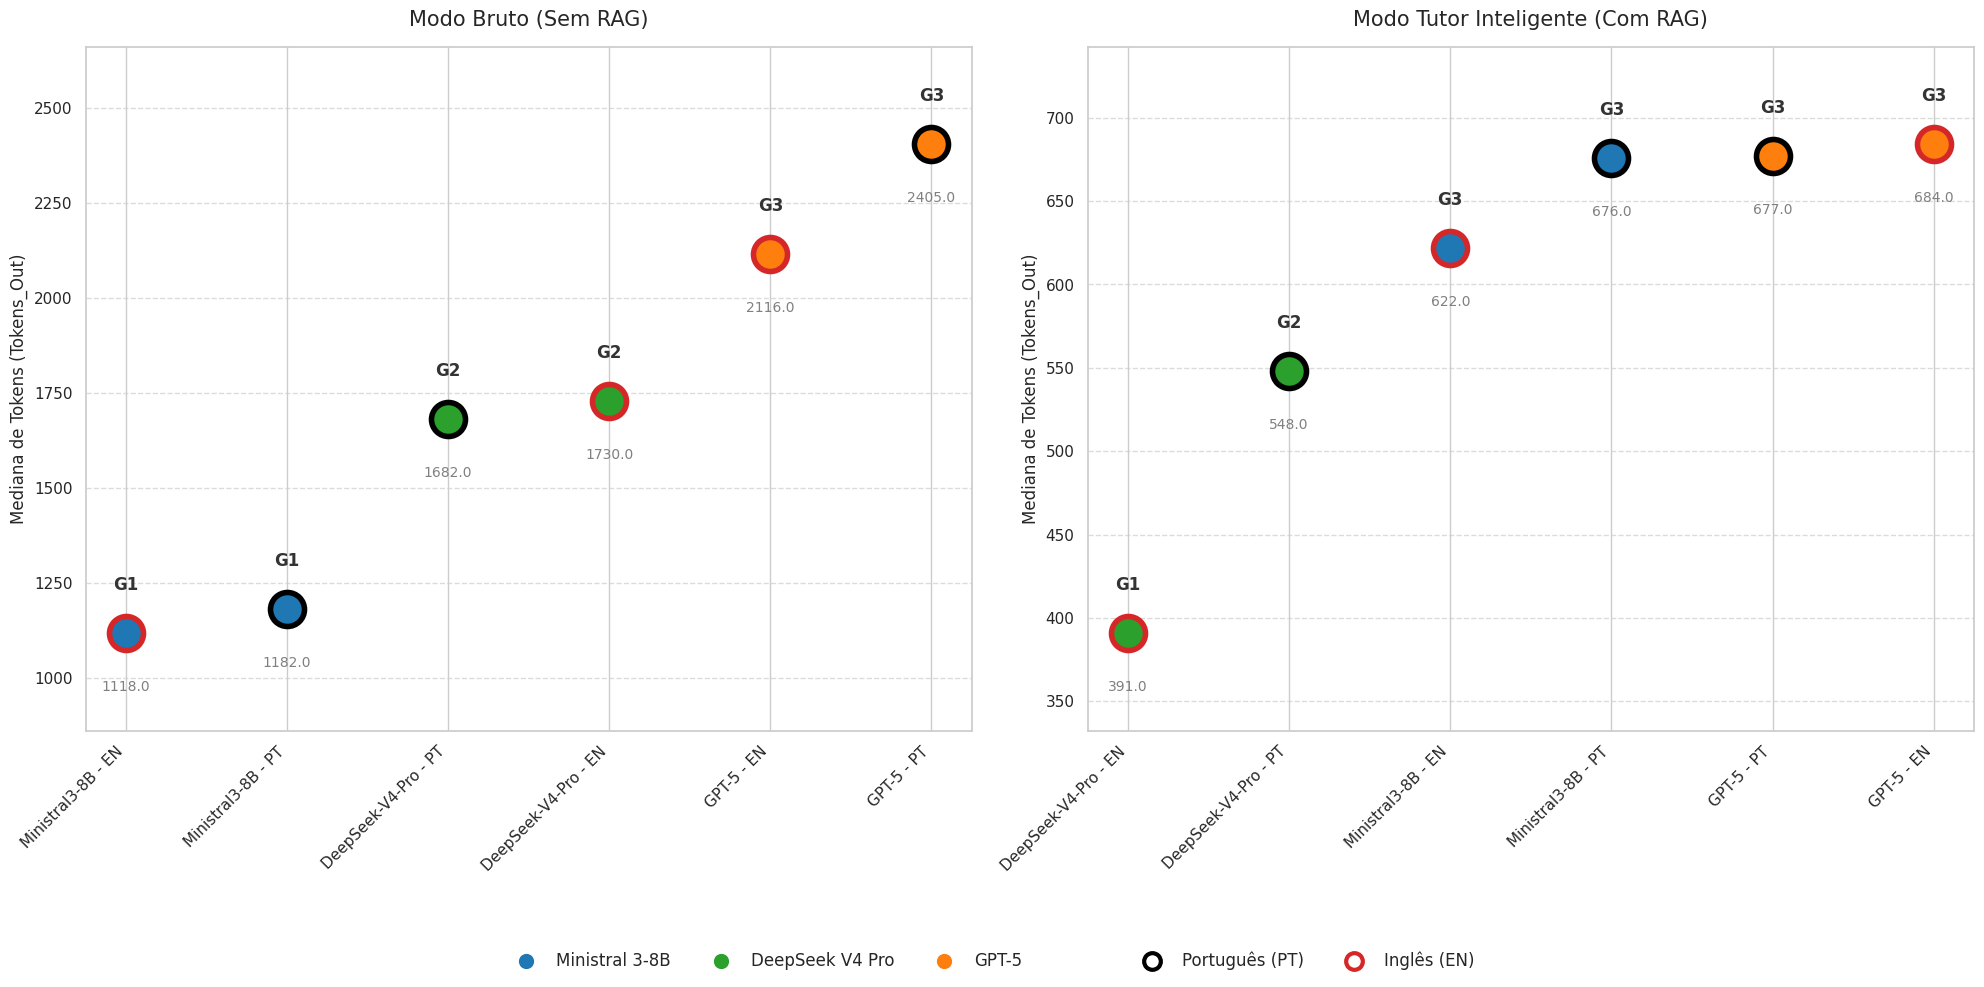

In [30]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 9), sharey=False)
#fig.suptitle('Mediana de Verbosidade por Modelo e Idioma (Mann-Whitney $\\alpha = 0.10$)', fontsize=18, fontweight='bold')

# Executa as plotagens
plotar_dotplot(axes[0], df_bruto, 'Modo Bruto (Sem RAG)')
plotar_dotplot(axes[1], df_tutor, 'Modo Tutor Inteligente (Com RAG)')

# ==========================================================
# LEGENDAS CUSTOMIZADAS (Para explicar Cor e Borda)
# ==========================================================
elementos_legenda = [
    # Legenda dos Modelos (Cor Interna) - Nomes corrigidos aqui também
    Line2D([0], [0], marker='o', color='w', markerfacecolor=cores_modelo['Ministral3-8B'], markersize=12, label='Ministral 3-8B'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=cores_modelo['DeepSeek-V4-Pro'], markersize=12, label='DeepSeek V4 Pro'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=cores_modelo['GPT-5'], markersize=12, label='GPT-5'),
    
    # Espaçador invisível
    Line2D([0], [0], marker='none', color='w', label=''), 
    
    # Legenda dos Idiomas (Contorno)
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=cores_idioma['PT'], markeredgewidth=3, markersize=12, label='Português (PT)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=cores_idioma['EN'], markeredgewidth=3, markersize=12, label='Inglês (EN)')
]

# Adiciona a legenda na figura global
fig.legend(handles=elementos_legenda, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=6, fontsize=12, frameon=False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2328240/3723293926.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_med['Variacao'], rotation=45, ha='right', fontsize=11)
/tmp/ipykernel_2328240/3723293926.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_med['Variacao'], rotation=45, ha='right', fontsize=11)


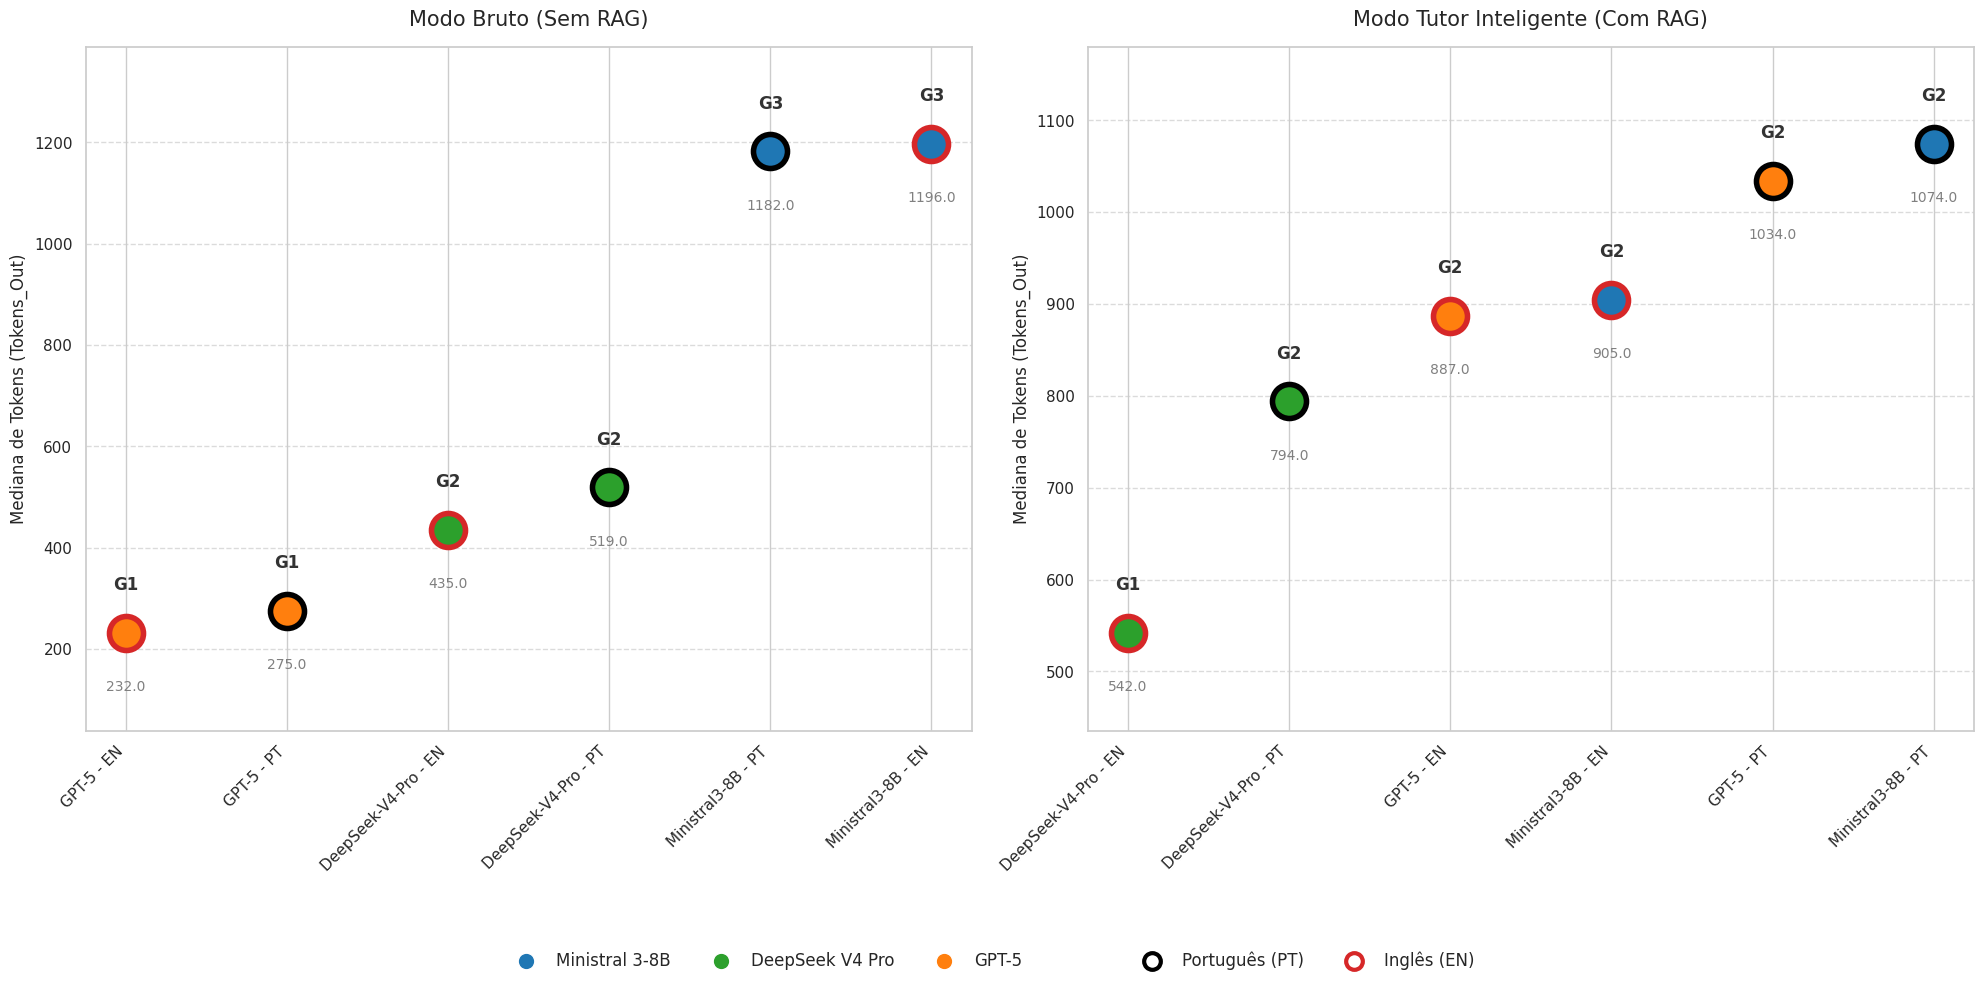

In [15]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 9), sharey=False)
#fig.suptitle('Mediana de Verbosidade por Modelo e Idioma (Mann-Whitney $\\alpha = 0.10$)', fontsize=18, fontweight='bold')

# Executa as plotagens
plotar_dotplot(axes[0], df_bruto, 'Modo Bruto (Sem RAG)')
plotar_dotplot(axes[1], df_tutor, 'Modo Tutor Inteligente (Com RAG)')

# ==========================================================
# LEGENDAS CUSTOMIZADAS (Para explicar Cor e Borda)
# ==========================================================
elementos_legenda = [
    # Legenda dos Modelos (Cor Interna) - Nomes corrigidos aqui também
    Line2D([0], [0], marker='o', color='w', markerfacecolor=cores_modelo['Ministral3-8B'], markersize=12, label='Ministral 3-8B'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=cores_modelo['DeepSeek-V4-Pro'], markersize=12, label='DeepSeek V4 Pro'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=cores_modelo['GPT-5'], markersize=12, label='GPT-5'),
    
    # Espaçador invisível
    Line2D([0], [0], marker='none', color='w', label=''), 
    
    # Legenda dos Idiomas (Contorno)
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=cores_idioma['PT'], markeredgewidth=3, markersize=12, label='Português (PT)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor=cores_idioma['EN'], markeredgewidth=3, markersize=12, label='Inglês (EN)')
]

# Adiciona a legenda na figura global
fig.legend(handles=elementos_legenda, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=6, fontsize=12, frameon=False)

plt.tight_layout()
plt.show()

A avaliação da quantidade mediana de tokens gerados (verbosidade) revela comportamentos estatisticamente distintos entre os modelos quando submetidos ao Modo Bruto (conhecimento paramétrico livre) e ao Modo Tutor Inteligente (arquitetura RAG com restrição de contexto). A partir do agrupamento gerado pelo teste de Mann-Whitney (alpha = 0,10), destacam-se os seguintes achados:

**1. O Efeito Restritivo do RAG (Concisão Universal)**
* A diferença mais expressiva ocorre na escala global de geração. No **Modo Bruto**, a mediana de tokens varia de aproximadamente 1.100 a 2.400 tokens. No **Modo Tutor**, as respostas são drasticamente encurtadas, variando entre 390 e 680 tokens.
* Isso comprova a eficácia da engenharia de *prompt* do sistema RAG, que exige respostas focadas exclusivamente no contexto fornecido, inibindo a tendência natural dos modelos de gerar textos longos, dedutivos ou prolixos.

**2. Modo Bruto: Hierarquia Natural dos Modelos**
* Sem as amarras do RAG, a verbosidade é estritamente ditada pela arquitetura do modelo, formando três grupos estatísticos perfeitamente delineados:
  * **Grupo 1 (Menor verbosidade):** Ministral 3-8B (~1.100 a 1.200 tokens).
  * **Grupo 2 (Verbosidade intermediária):** DeepSeek V4 Pro (~1.680 a 1.730 tokens).
  * **Grupo 3 (Maior verbosidade):** GPT-5 (~2.100 a 2.400 tokens).
* O idioma da requisição (PT vs. EN) causou flutuações matemáticas pontuais — como o GPT-5 em português exigindo mais tokens que em inglês para a mesma tarefa — porém insuficientes para alterar o agrupamento estatístico na faixa de significância adotada.

**3. Modo Tutor: A "Domesticação" pelo Contexto**
* A introdução do RAG alterou radicalmente a dinâmica de geração entre as IA:
  * **A Rigidez do DeepSeek:** O modelo V4 Pro, que possuía verbosidade intermediária no modo bruto, tornou-se o **mais conciso** sob o RAG. Esse comportamento corrobora o alto grau de alinhamento do modelo às regras de restrição do *System Prompt* (recusando-se a preencher a resposta com conhecimento paramétrico caso a informação não conste nos *chunks* recuperados). Houve, inclusive, uma separação estatística inédita por idioma: as respostas em inglês (G1) foram significativamente mais curtas que em português (G2).
  * **Nivelamento no Topo:** O Ministral 3-8B e o GPT-5, apesar de figurarem em extremos opostos no modo bruto, foram estatisticamente igualados pela arquitetura RAG. Ambos convergiram para o **Grupo 3** (entre 620 e 680 tokens). Isso indica que o volume textual dos *chunks* do banco vetorial passou a atuar como um "teto universal" de verbosidade para modelos mais criativos, forçando-os a gerar quantidades de texto estatisticamente semelhantes para sintetizar a mesma informação.